# Teddy Baeny – Assignment 4
# Part 1: Data Cleaning

The first step involves loading the libraries needed, then calculating missing values, duplicate rows, and looking at the dataset shape and data types.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

crime_df = pd.read_csv('crime_dataset.csv')
crime_types_df = pd.read_csv('crime_types.csv')
weapon_types_df = pd.read_csv('weapon_types.csv')

print('Crime dataset:')
print(crime_df.head())
print('Dataset shape:', crime_df.shape)
print('\nData types:\n', crime_df.dtypes)
print('Missing values per column:\n', crime_df.isnull().sum())
print('Duplicate rows:', crime_df.duplicated().sum())

Crime dataset:
   division_number date_reported        date_occurred  area area_name  \
0        211414090    2021-06-27  2021-06-20 20:00:00    14   Pacific   
1        210504861    2021-01-22  2021-01-21 22:00:00     5    Harbor   
2        210104843    2021-01-21  2021-01-21 02:00:00     1   Central   
3        210115564    2021-08-22  2021-08-22 07:00:00     1   Central   
4        211421187    2021-11-09  2021-11-07 19:00:00    14   Pacific   

   reporting_district  part  crime_code       modus_operandi  victim_age  ...  \
0                1464     1         480                 0344        32.0  ...   
1                 515     1         510                  NaN         0.0  ...   
2                 139     1         510                  NaN         0.0  ...   
3                 151     1         350  1308 0344 0345 1822        29.0  ...   
4                1465     1         510                  NaN         0.0  ...   

  crime_code_1 crime_code_2  crime_code_3 crime_code_4  inc

After the first step, there are some changes to make for the dataset:

1. Set date columns in the correct format
2. Normalize gender values as some are M, Male, X, etc.
3. Drop irrelevant columns with many missing values
4. Fill missing values in age with the median (as an integer)
5. Fill missing gender, ethnicity and weapon_code with Unknown or 0

In [ ]:
crime_df['date_reported'] = pd.to_datetime(crime_df['date_reported'], errors='coerce')
crime_df['date_occurred'] = pd.to_datetime(crime_df['date_occurred'], errors='coerce')

crime_df['victim_gender'] = crime_df['victim_gender'].replace({
    'M': 'Male', 'F': 'Female', 'X': 'Other', 'H': 'Other'
})

cols_to_drop = ['crime_code_2', 'crime_code_3', 'crime_code_4', 'cross_street']
crime_df.drop(columns=cols_to_drop, inplace=True)

median_age = int(crime_df['victim_age'].median())
crime_df['victim_age'] = crime_df['victim_age'].fillna(median_age).astype(int)

crime_df['victim_gender'] = crime_df['victim_gender'].fillna('Unknown')
crime_df['victim_ethnicity'] = crime_df['victim_ethnicity'].fillna('Unknown')
crime_df['weapon_code'] = crime_df['weapon_code'].fillna(0).astype(int)

print('\nCleaned dataset preview:')
print(crime_df.head())
print('\nData types:\n', crime_df.dtypes)


Cleaned dataset preview:
   division_number date_reported       date_occurred  area area_name  \
0        211414090    2021-06-27 2021-06-20 20:00:00    14   Pacific   
1        210504861    2021-01-22 2021-01-21 22:00:00     5    Harbor   
2        210104843    2021-01-21 2021-01-21 02:00:00     1   Central   
3        210115564    2021-08-22 2021-08-22 07:00:00     1   Central   
4        211421187    2021-11-09 2021-11-07 19:00:00    14   Pacific   

   reporting_district  part  crime_code       modus_operandi  victim_age  ...  \
0                1464     1         480                 0344          32  ...   
1                 515     1         510                  NaN           0  ...   
2                 139     1         510                  NaN           0  ...   
3                 151     1         350  1308 0344 0345 1822          29  ...   
4                1465     1         510                  NaN           0  ...   

  victim_ethnicity premise_code  premise_description w

# Part 2: Exploratory Data Analysis

Merge the 3 datasets together, extract time features, and get summary statistics.

In [ ]:
crime_df = crime_df.merge(crime_types_df, on='crime_code', how='left')
crime_df = crime_df.merge(weapon_types_df, on='weapon_code', how='left')
print('\nMerged dataset preview:')
print(crime_df.head())

crime_df['year'] = crime_df['date_occurred'].dt.year
crime_df['month'] = crime_df['date_occurred'].dt.month
crime_df['day_of_week'] = crime_df['date_occurred'].dt.day_name()

summary_stats = crime_df.describe()
print('\nSummary statistics:')
print(summary_stats)


Merged dataset preview:
   division_number date_reported       date_occurred  area area_name  \
0        211414090    2021-06-27 2021-06-20 20:00:00    14   Pacific   
1        210504861    2021-01-22 2021-01-21 22:00:00     5    Harbor   
2        210104843    2021-01-21 2021-01-21 02:00:00     1   Central   
3        210115564    2021-08-22 2021-08-22 07:00:00     1   Central   
4        211421187    2021-11-09 2021-11-07 19:00:00    14   Pacific   

   reporting_district  part  crime_code       modus_operandi  victim_age  ...  \
0                1464     1         480                 0344          32  ...   
1                 515     1         510                  NaN           0  ...   
2                 139     1         510                  NaN           0  ...   
3                 151     1         350  1308 0344 0345 1822          29  ...   
4                1465     1         510                  NaN           0  ...   

  premise_description weapon_code  crime_code_1 inciden

# Part 3: Visualizations

### 1) Victim Age Distribution

Knowing the distribution of the main numerical variable in the dataset is very important for the analysis. As it can be seen, there are many values where age is 0 which represents vehicle or bike theft where the victim's age is not always known or important. For this reason, it is also important to analyze the distribution without these values, where the distribution is right-skewed with more values around 30 years old.

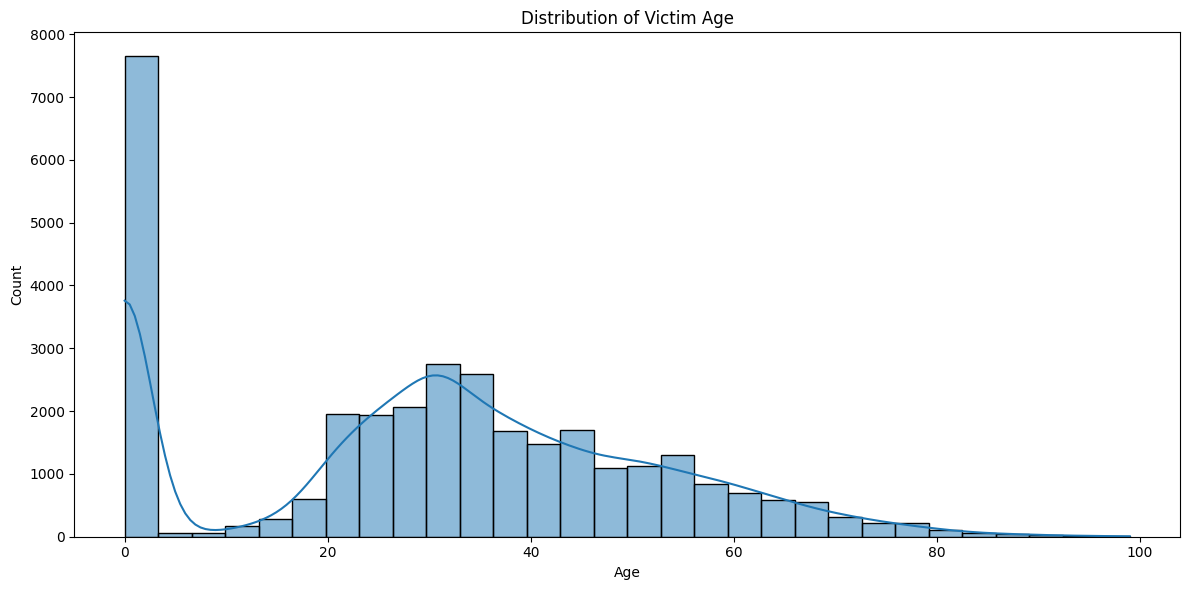

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(crime_df['victim_age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Victim Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

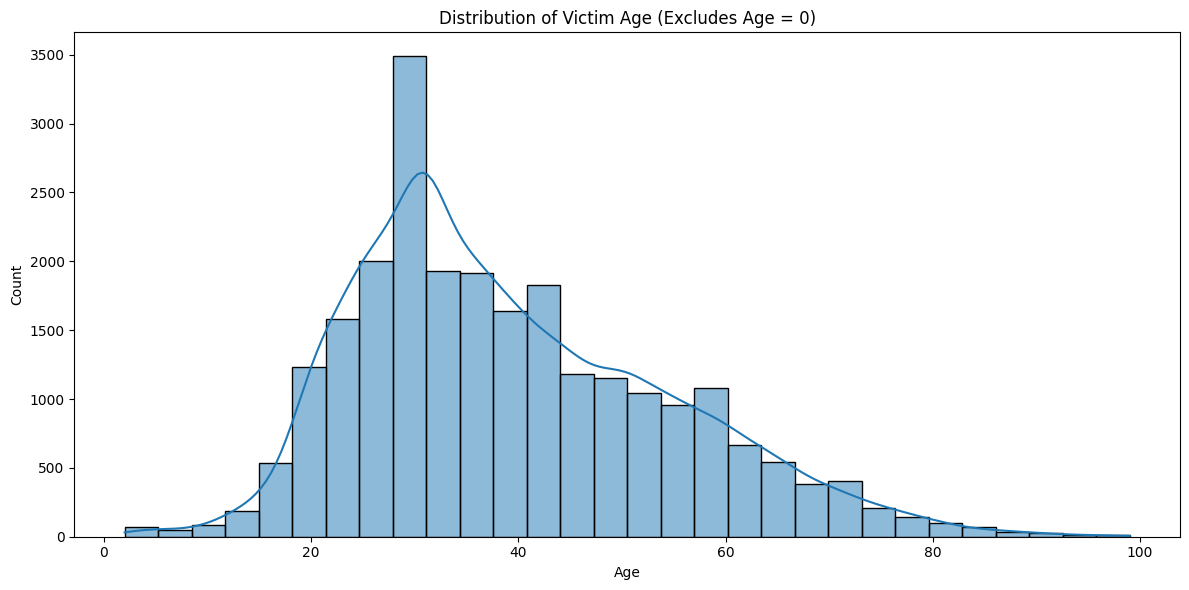

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(crime_df[crime_df['victim_age'] > 0]['victim_age'], bins=30, kde=True)
plt.title('Distribution of Victim Age (Excludes Age = 0)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2) Top 10 Reported Crimes

This graph shows the top 10 most common crimes in the dataset, led by stolen vehicle (Grand Theft Auto) followed by Battery and Vandalism.

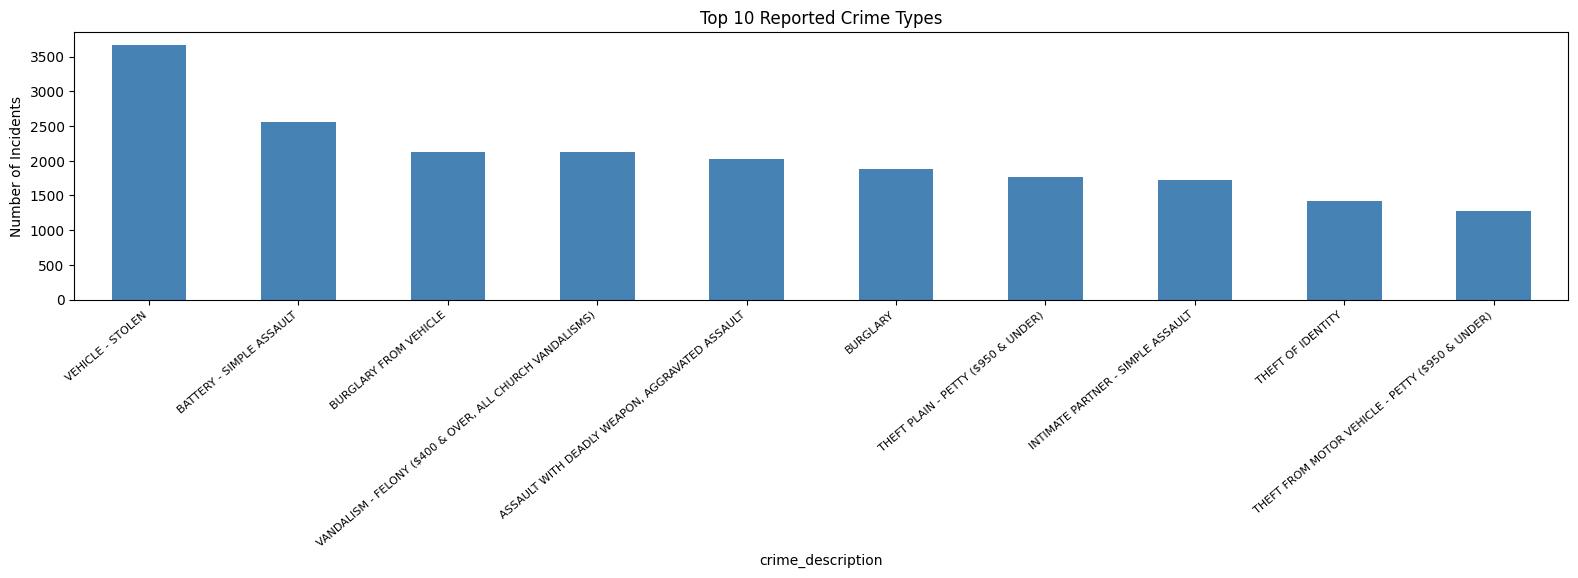

In [ ]:
plt.figure(figsize=(16, 6))
crime_df['crime_description'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Reported Crime Types', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout(pad=1.5)
plt.show()

### 3) Top 10 Weapons Used in Crimes

The bar chart shows the most used weapons for crimes. Hand or bodily force is the most common by a large margin, followed by unknown/other weapons and verbal threats, indicating most crimes do not involve firearms or bladed weapons.

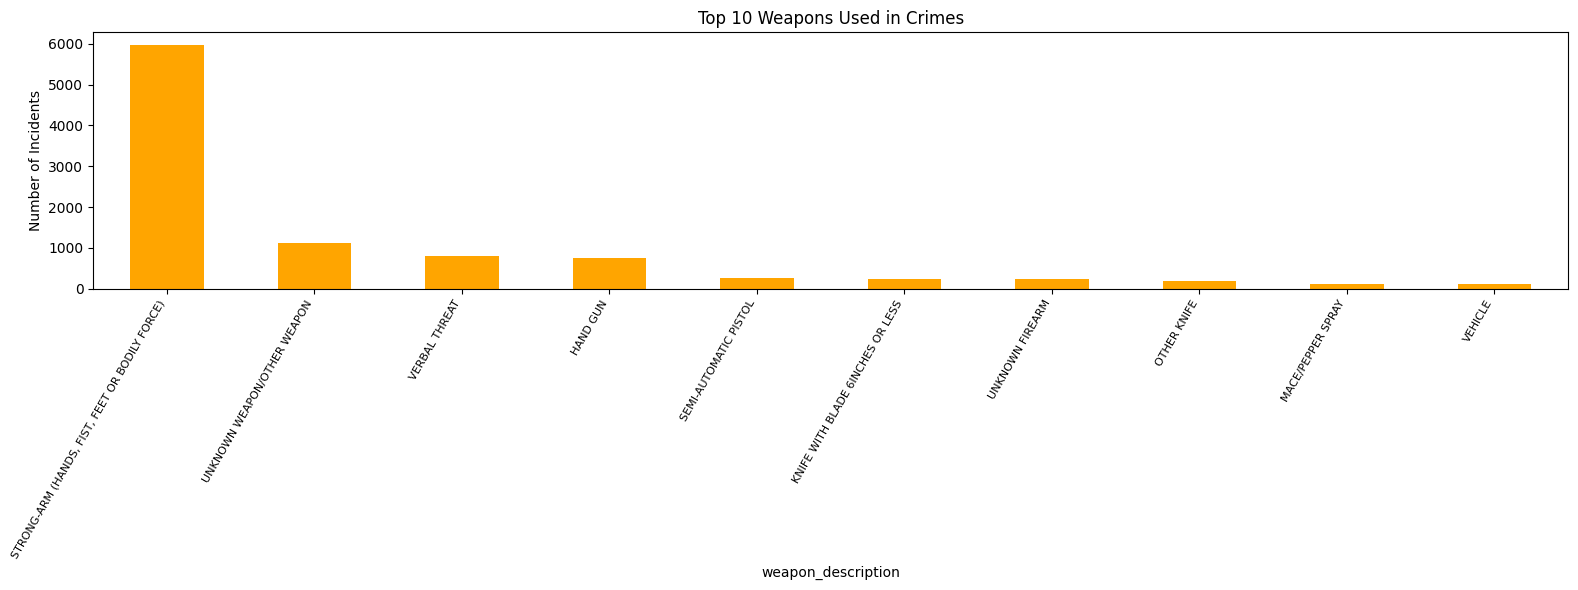

In [ ]:
plt.figure(figsize=(16, 6))
crime_df['weapon_description'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Weapons Used in Crimes', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=10)
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### 4) Correlation Heatmap

The correlation heatmap uses 4 numerical variables. `case_solved` is converted to a binary dummy (1 = Solved, 0 = Not Solved). The heatmap shows weak correlations between this variable and the others, which is expected given the complexity of the problem.

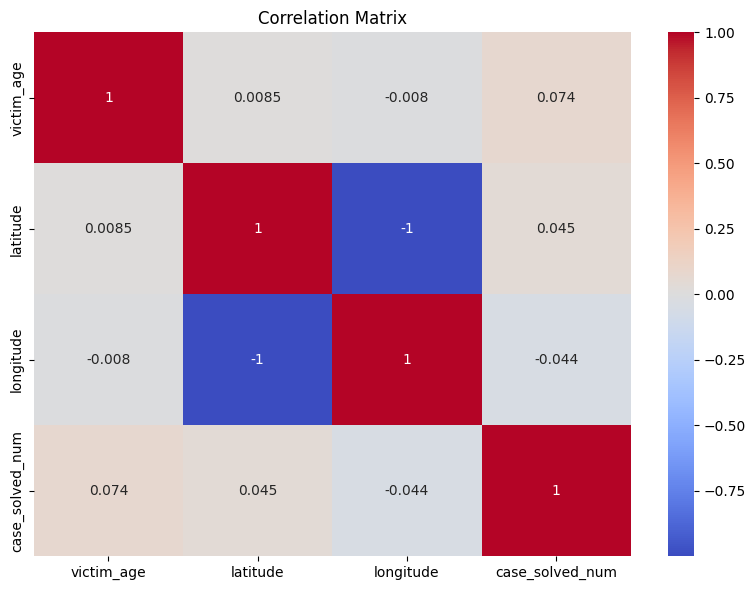

In [ ]:
crime_df['case_solved_num'] = crime_df['case_solved'].map({'Solved': 1, 'Not solved': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(crime_df[['victim_age', 'latitude', 'longitude', 'case_solved_num']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 5) Crimes by Month

The bar chart shows the distribution of crimes by month. All months show similar values, though there is a slight increase during summer and fall compared to other seasons.

/tmp/ipykernel_16583/1001686263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=crime_df, x='month', palette='viridis')


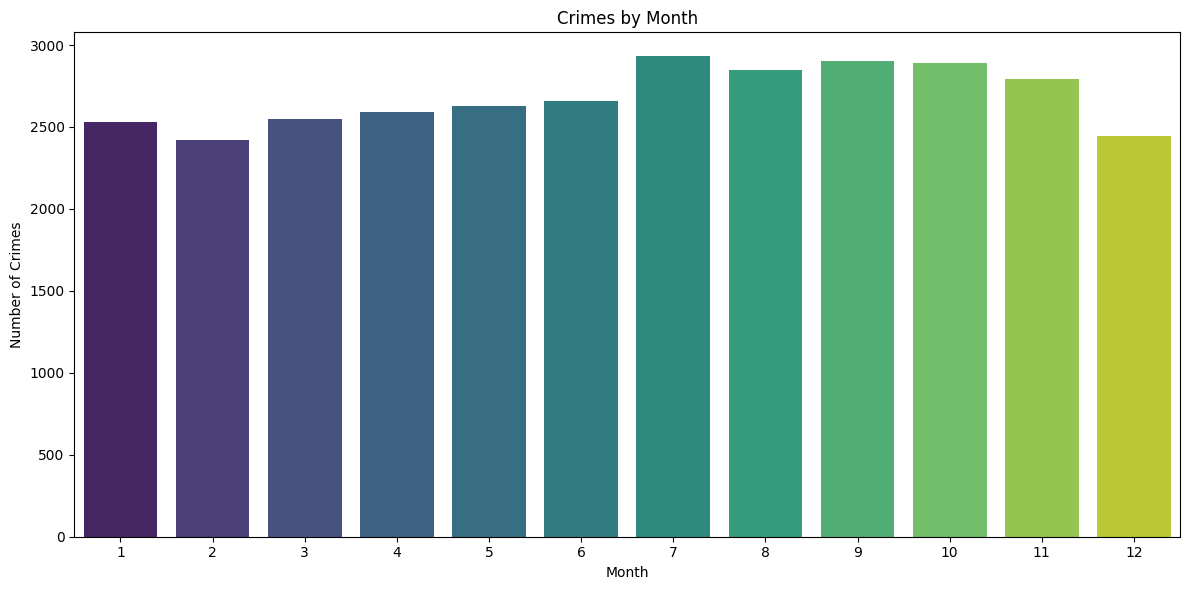

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=crime_df, x='month', palette='viridis')
plt.title('Crimes by Month')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()

### 6) Crimes by Day of the Week

Friday shows the highest number of incidents, but values are similar across all days, suggesting no single day is dramatically more dangerous.

/tmp/ipykernel_16583/3906386195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=crime_df, x='day_of_week',


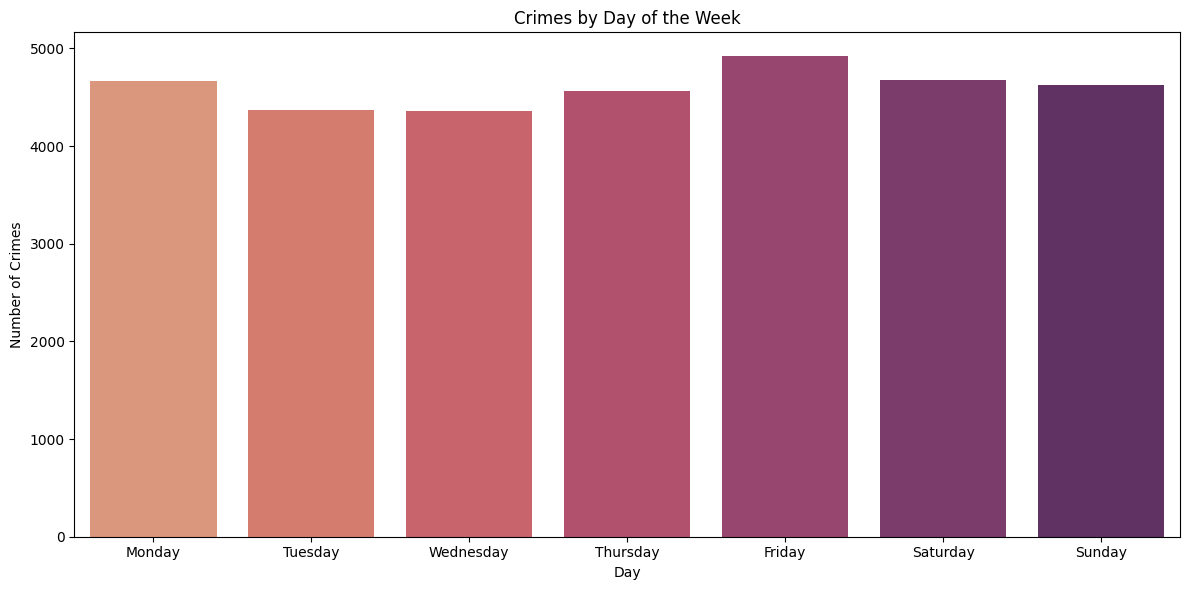

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=crime_df, x='day_of_week',
              order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
              palette='flare')
plt.title('Crimes by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()

### 7) Solve Rate by Area

The stacked bar chart shows the proportion of solved vs. unsolved cases by neighborhood. Most areas show solve rates between 20–30%, with the majority of cases remaining unsolved across all areas of Los Angeles.

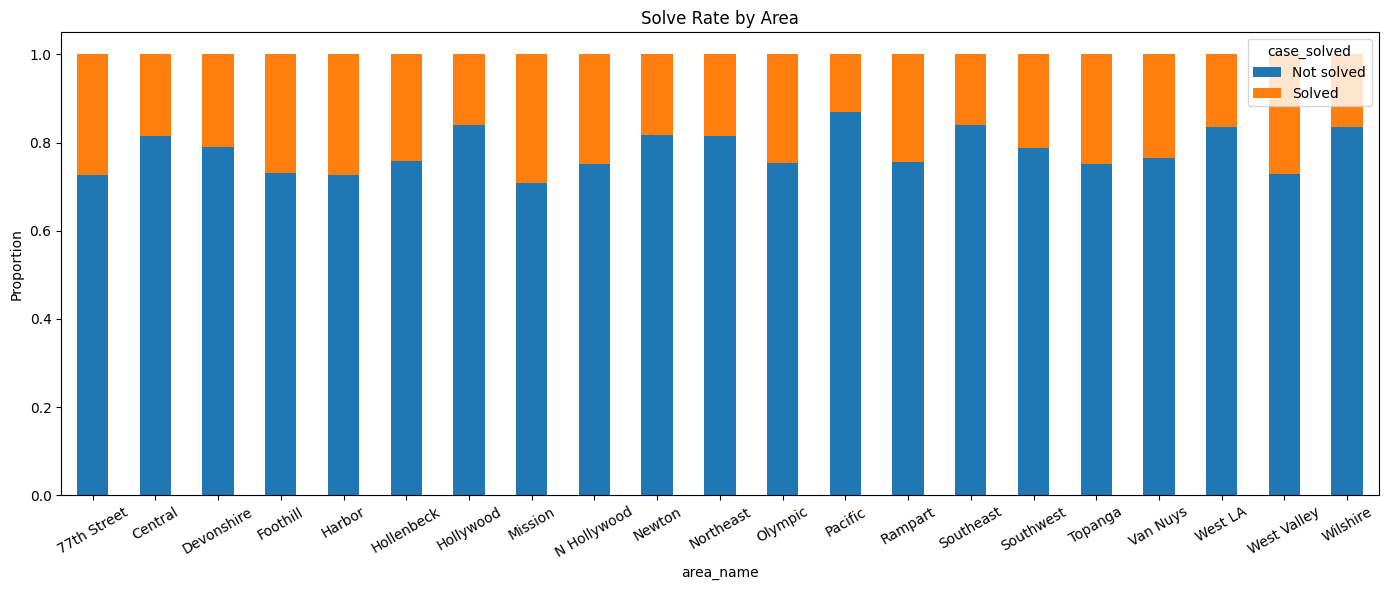

In [ ]:
solve_rate_area = crime_df.groupby('area_name')['case_solved'].value_counts(normalize=True).unstack().fillna(0)
solve_rate_area.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Solve Rate by Area')
plt.ylabel('Proportion')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 8) Solve Rate by Victim Gender

Female victims tend to have slightly more solved cases than male victims. Crimes where the gender is unknown are almost never solved, which is consistent with cases that lack victim information.

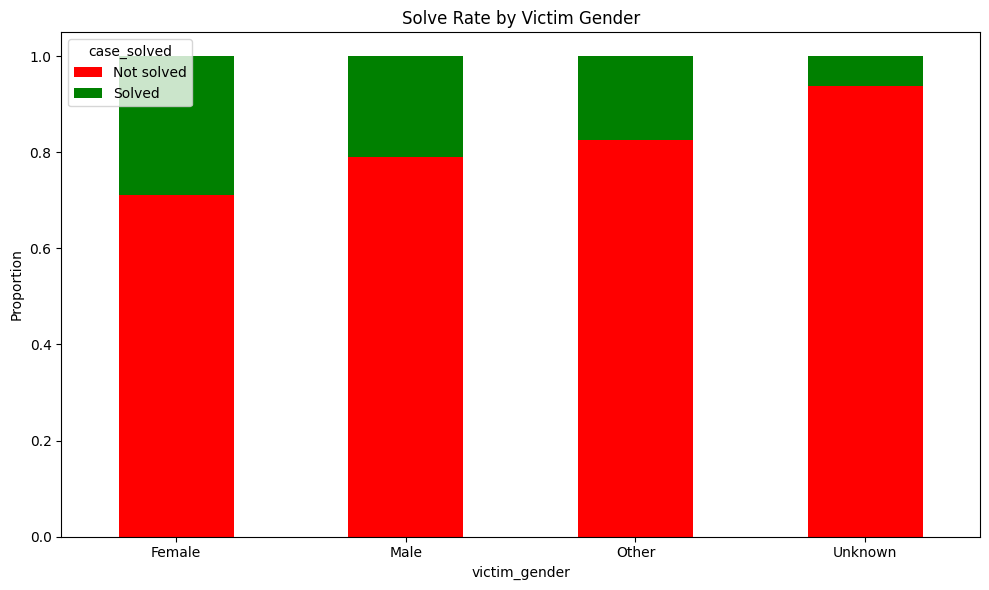

In [ ]:
solve_rate_gender = crime_df.groupby('victim_gender')['case_solved'].value_counts(normalize=True).unstack().fillna(0)
solve_rate_gender.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'green'])
plt.title('Solve Rate by Victim Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9) Solve Rate by Weapon Type (Top 20)

Crimes involving bladed weapons tend to have higher solve rates. Firearm-related crimes show lower solve rates, with unsolved cases approaching half in some weapon categories.

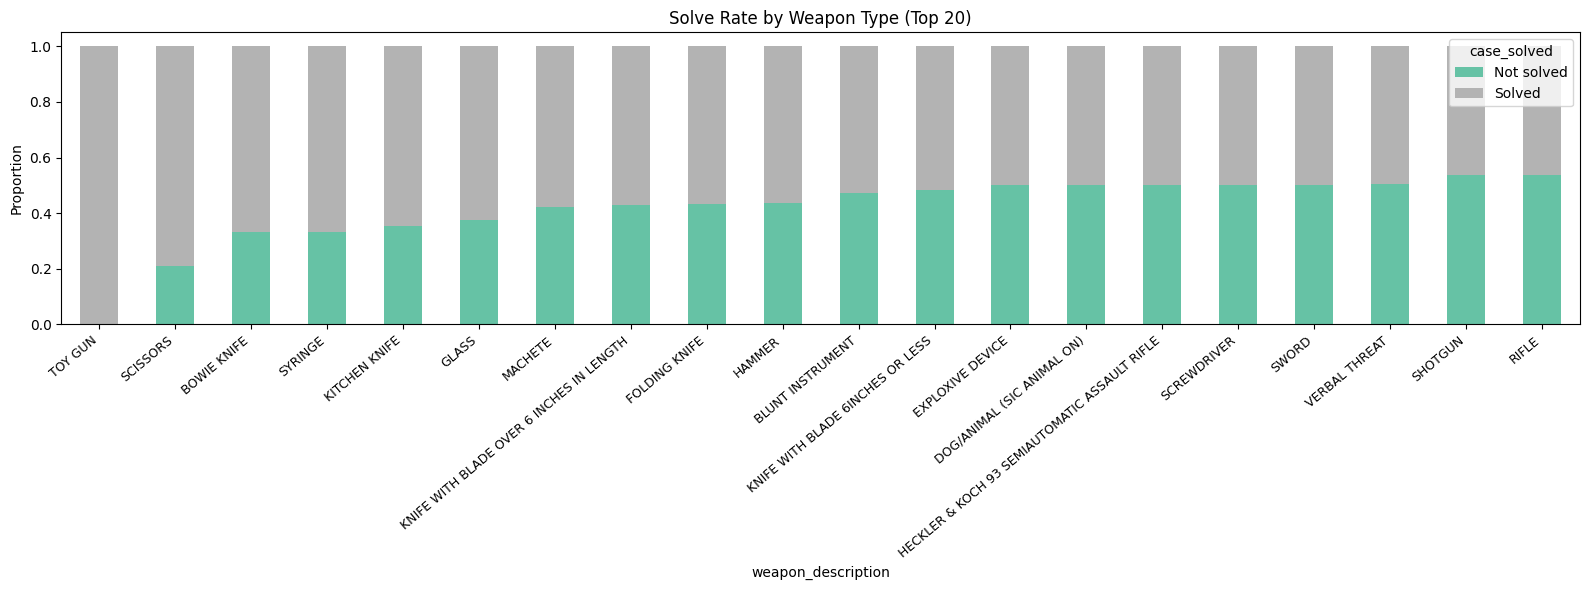

In [ ]:
solve_rate_weapon = crime_df.groupby('weapon_description')['case_solved'].value_counts(normalize=True).unstack().fillna(0)
solve_rate_weapon = solve_rate_weapon.sort_values(by='Solved', ascending=False).head(20)
solve_rate_weapon.plot(kind='bar', stacked=True, figsize=(16, 6), colormap='Set2')
plt.title('Solve Rate by Weapon Type (Top 20)')
plt.ylabel('Proportion')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Part 4: Feature Engineering

The first step imports the libraries needed for preprocessing and sets the random seed for reproducibility.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

np.random.seed(42)

New features are added: hour of the crime, weekend flag, weapon usage flag, and an age group classification. The age group handles the 0-value cases (non-person crimes like vehicle theft) as a separate category so they don't skew the model.

Crime categories are assigned using **mutually exclusive** groupings based on the crime code lookup table — violent, property, public order, and other — with no overlapping codes between categories.

In [ ]:
crime_df['hour'] = crime_df['date_occurred'].dt.hour
crime_df['is_weekend'] = crime_df['date_occurred'].dt.dayofweek.isin([5, 6]).astype(int)
crime_df['weapon_used'] = (crime_df['weapon_code'] > 0).astype(int)

bins = [-1, 0, 18, 35, 60, 100]
labels = ['Non-Person', 'Young', 'Adult', 'Senior', 'Elderly']
crime_df['age_group'] = pd.cut(crime_df['victim_age'], bins=bins, labels=labels)

# Crime categories — mutually exclusive, based on lookup table codes
# Violent: homicide, robbery, assault, shots fired, kidnapping, sexual assault
violent_codes = [
    110, 113, 121, 122, 210, 220, 230, 231, 235, 236, 237, 250, 251,
    434, 435, 436, 622, 623, 624, 625, 626, 627, 647, 753, 755, 756,
    760, 761, 762, 763, 810, 812, 813, 814, 815, 820, 821, 822, 830,
    840, 860, 910, 920, 921, 922, 928, 930, 940
]

# Property: burglary, theft, vehicle theft, fraud, arson, vandalism
property_codes = [
    310, 320, 330, 331, 341, 343, 345, 347, 350, 351, 352, 353, 354,
    410, 420, 421, 433, 440, 441, 442, 443, 444, 446, 450, 451, 452,
    470, 471, 473, 474, 480, 485, 487, 510, 520, 522,
    648, 649, 651, 652, 653, 654, 660, 661, 662, 664, 666, 668, 670,
    740, 745
]

# Public Order: violations, drugs, sex offenses not above, misc
public_order_codes = [
    437, 438, 439, 805, 806, 845, 850, 865, 870, 880, 884, 886, 888,
    890, 900, 901, 902, 903, 904, 906, 924, 931, 932, 933, 942, 943,
    944, 946, 948, 949, 950, 951, 954, 956
]

def categorize_crime(code):
    if pd.isna(code):
        return 'Other'
    code = int(code)
    if code in violent_codes:
        return 'Violent'
    elif code in property_codes:
        return 'Property'
    elif code in public_order_codes:
        return 'Public Order'
    return 'Other'

crime_df['crime_category'] = crime_df['crime_code'].apply(categorize_crime)

print('Crime category distribution:')
print(crime_df['crime_category'].value_counts())

Crime category distribution:
crime_category
Property        19411
Violent         10709
Public Order     2059
Name: count, dtype: int64


Define the features and target variable. Numeric features will be standardized; categorical features will be one-hot encoded. Note that `is_weekend` and `weapon_used` are binary flags and are treated as numeric features.

In [ ]:
variables = [
    'victim_gender', 'victim_ethnicity', 'area_name', 'crime_category',
    'weapon_used', 'hour', 'month', 'is_weekend', 'latitude', 'longitude', 'age_group'
]
target = 'case_solved_num'

# Binary flags (weapon_used, is_weekend) are numeric — no need to one-hot encode them
numeric_variables = ['hour', 'month', 'latitude', 'longitude', 'weapon_used', 'is_weekend']
categorical_variables = ['victim_gender', 'victim_ethnicity', 'area_name', 'crime_category', 'age_group']

# Define the preprocessor — fit happens inside the pipeline on training data only
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_variables),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_variables)
    ]
)

# Part 5: Model Building

The dataset is split into training (80%) and testing (20%) sets using stratified sampling to preserve the class imbalance ratio. Both models are built inside sklearn Pipelines so that the preprocessor is **only fitted on training data**, preventing data leakage.

Logistic Regression uses `class_weight='balanced'` to handle the class imbalance (roughly 79% unsolved vs. 21% solved). Random Forest is tuned with GridSearchCV using F1-score as the optimization metric.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score

crime_df_cleaned = crime_df.dropna(subset=[target])
X_cleaned = crime_df_cleaned[variables]
y_cleaned = crime_df_cleaned[target]

# Stratified split preserves the 79/21 class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.2, stratify=y_cleaned, random_state=42
)

print(f'Training set size: {X_train.shape[0]:,}')
print(f'Test set size:     {X_test.shape[0]:,}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set size: 25,742
Test set size:     6,436

Class distribution in training set:
case_solved_num
0.0    0.785
1.0    0.215
Name: proportion, dtype: float64


### Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression training complete.')

Logistic Regression training complete.


### Random Forest with GridSearchCV

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [25, 30],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2]
}

f1_scorer = make_scorer(f1_score, pos_label=1)
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring=f1_scorer, n_jobs=-1)
grid_search.fit(X_train, y_train)

rf_best = grid_search.best_estimator_

print(f'Best Random Forest parameters: {grid_search.best_params_}')
print(f'Best cross-validation F1 score: {grid_search.best_score_:.2f}')

Best Random Forest parameters: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best cross-validation F1 score: 0.54


# Part 6: Model Evaluation

Both models are evaluated using accuracy, precision, recall, F1-score, and AUC-ROC. Confusion matrices and ROC curves are included to visualize performance. Class imbalance (79% unsolved, 21% solved) is addressed through `class_weight='balanced'` in both models.


Logistic Regression Results:
  Accuracy:  0.73
  Precision: 0.44
  Recall:    0.78
  F1-Score:  0.56
  AUC-ROC:   0.80


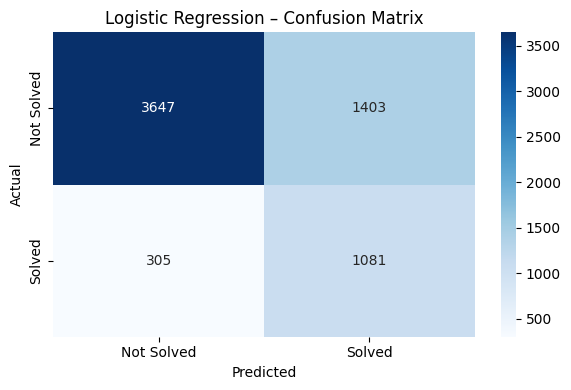

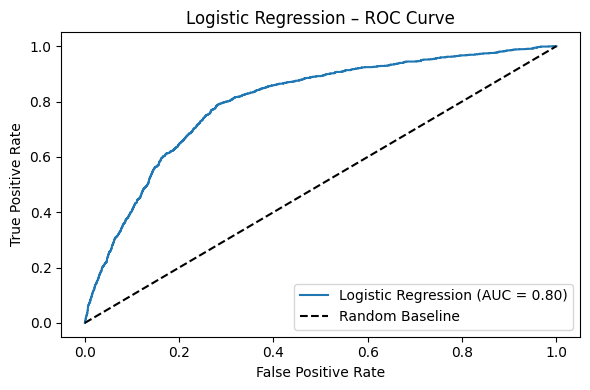


Random Forest Results:
  Accuracy:  0.77
  Precision: 0.47
  Recall:    0.67
  F1-Score:  0.55
  AUC-ROC:   0.80


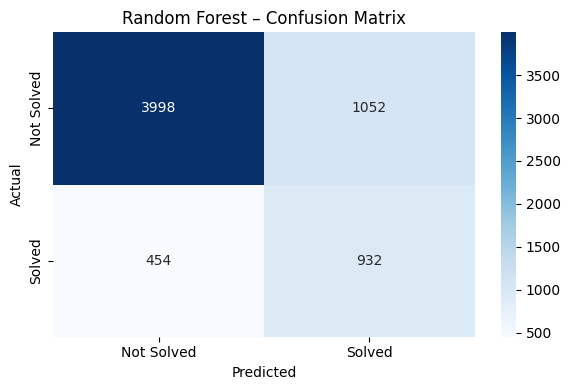

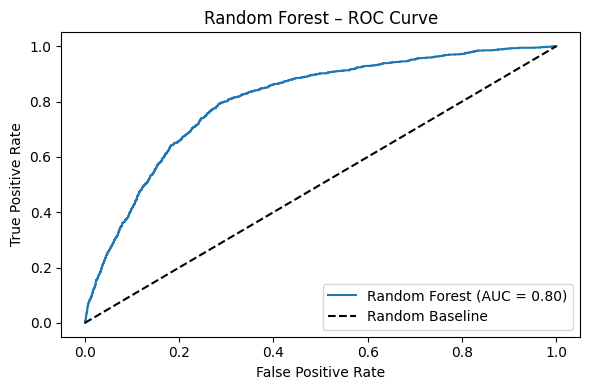

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f'\n{model_name} Results:')
    print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.2f}')
    print(f'  Precision: {precision_score(y_test, y_pred, pos_label=1):.2f}')
    print(f'  Recall:    {recall_score(y_test, y_pred, pos_label=1):.2f}')
    print(f'  F1-Score:  {f1_score(y_test, y_pred, pos_label=1):.2f}')
    print(f'  AUC-ROC:   {roc_auc_score(y_test, y_prob):.2f}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Solved', 'Solved'],
                yticklabels=['Not Solved', 'Solved'])
    plt.title(f'{model_name} – Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_prob):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} – ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_model(lr_pipeline, X_test, y_test, 'Logistic Regression')
evaluate_model(rf_best, X_test, y_test, 'Random Forest')

### Feature Importance (Random Forest)

The Random Forest model provides feature importances that show which variables contribute most to predicting case solvability. The top 20 most important features are shown below.

/tmp/ipykernel_16583/917536787.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


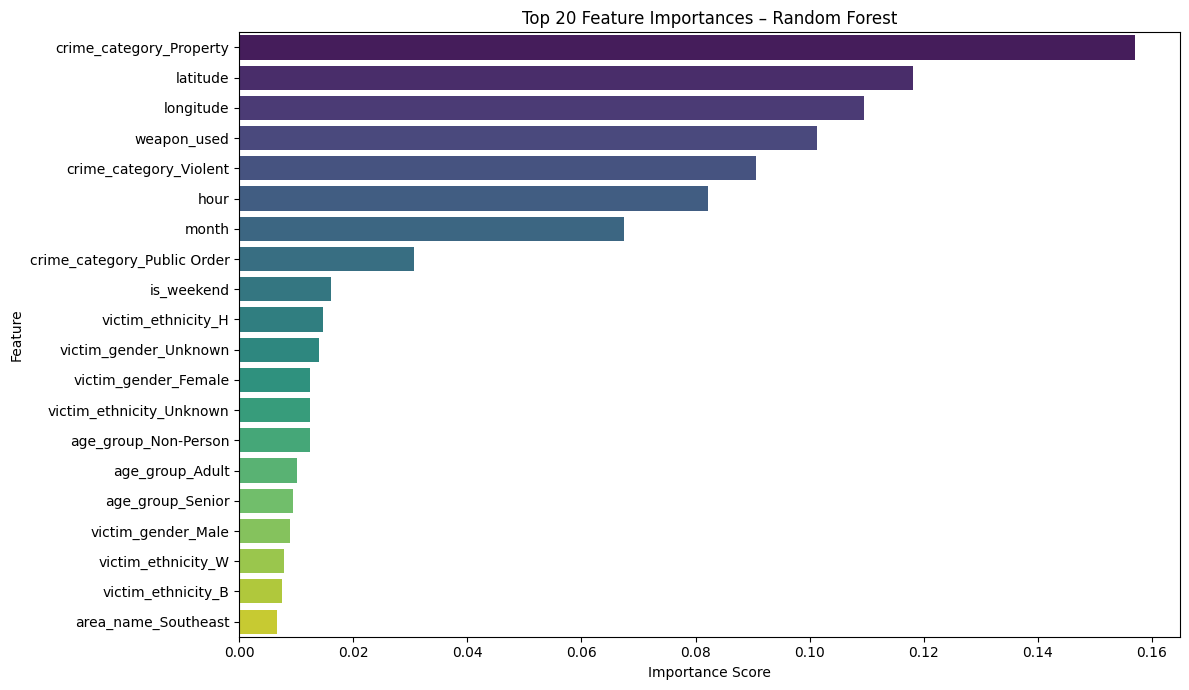


Top 10 most important features:
                    Feature  Importance
    crime_category_Property    0.157049
                   latitude    0.118040
                  longitude    0.109528
                weapon_used    0.101251
     crime_category_Violent    0.090569
                       hour    0.082136
                      month    0.067426
crime_category_Public Order    0.030707
                 is_weekend    0.016149
         victim_ethnicity_H    0.014714


In [ ]:
# Extract feature names from the fitted pipeline
rf_preprocessor = rf_best.named_steps['preprocessor']
cat_feature_names = rf_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_variables).tolist()
all_feature_names = numeric_variables + cat_feature_names

# Get importances from the fitted classifier
importances = rf_best.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(feature_importance_df.head(10).to_string(index=False))

### Model Comparison Summary

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, pos_label=1), 3),
        'Recall':    round(recall_score(y_test, y_pred, pos_label=1), 3),
        'F1-Score':  round(f1_score(y_test, y_pred, pos_label=1), 3),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 3)
    }

comparison = pd.DataFrame({
    'Logistic Regression': get_metrics(lr_pipeline, X_test, y_test),
    'Random Forest':       get_metrics(rf_best, X_test, y_test)
})

print('\nModel Comparison Summary:')
print(comparison)


Model Comparison Summary:
           Logistic Regression  Random Forest
Accuracy                 0.735          0.766
Precision                0.435          0.470
Recall                   0.780          0.672
F1-Score                 0.559          0.553
AUC-ROC                  0.799          0.804
